# New York Housing Dataset — Full Analysis

This notebook performs a complete exploratory analysis of the **NY House Dataset** (~4,800 listings).  
It covers:
- Data loading & inspection
- Filtering with pandas
- Summary statistics (min, max, mean, maps)
- Charts: Price distributions, geographic scatter, heatmaps
- Interactive map with Folium

---

## 1 · Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings

warnings.filterwarnings('ignore')

# ── visual style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})
PALETTE = '#1A56DB'
print('Libraries loaded ✓')

## 2 · Load & Inspect

In [2]:
CSV_PATH = '/mnt/user-data/uploads/NY-House-Dataset.csv'

df_raw = pd.read_csv(CSV_PATH)
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Shape: 4,801 rows × 17 columns


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [3]:
# Column types & null counts
info = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'nulls': df_raw.isnull().sum(),
    'null_%': (df_raw.isnull().mean() * 100).round(1)
})
info

,dtype,nulls,null_%
BROKERTITLE,str,0,0.0
TYPE,str,0,0.0
PRICE,int64,0,0.0
BEDS,int64,0,0.0
BATH,float64,0,0.0
PROPERTYSQFT,float64,0,0.0
ADDRESS,str,0,0.0
STATE,str,0,0.0
MAIN_ADDRESS,str,0,0.0
ADMINISTRATIVE_AREA_LEVEL_2,str,0,0.0


In [4]:
# Numeric summary
df_raw[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']].describe().round(2)

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.00,4801.00,4801.00,4801.00,4801.00
mean,2.356940e+06,3.36,2.37,2184.21,40.71,-73.94
std,3.135525e+07,2.60,1.95,2377.14,0.09,0.10
min,2.494000e+03,1.00,0.00,230.00,40.50,-74.25
25%,4.990000e+05,2.00,1.00,1200.00,40.64,-73.99
50%,8.250000e+05,3.00,2.00,2184.21,40.73,-73.95
75%,1.495000e+06,4.00,3.00,2184.21,40.77,-73.87
max,2.147484e+09,50.00,50.00,65535.00,40.91,-73.70


## 3 · Cleaning & Filtering

We apply several pandas filters to produce a **clean, analysis-ready** subset.

In [5]:
# ── Step 1: drop extreme price outliers (keep 1st–99th percentile) ──
p_lo, p_hi = df_raw['PRICE'].quantile([0.01, 0.99])
print(f'Price 1st pct: ${p_lo:,.0f}   99th pct: ${p_hi:,.0f}')

df = df_raw[
    (df_raw['PRICE'].between(p_lo, p_hi)) &          # price in range
    (df_raw['BEDS'] > 0) &                            # has at least 1 bed
    (df_raw['BATH'] > 0) &                            # has at least 1 bath
    (df_raw['PROPERTYSQFT'] > 0) &                    # has valid sqft
    (df_raw['LATITUDE'].between(40.4, 41.0)) &        # valid NYC lat
    (df_raw['LONGITUDE'].between(-74.3, -73.6))       # valid NYC lon
].copy()

# ── Step 2: add derived columns ──
df['PRICE_PER_SQFT'] = (df['PRICE'] / df['PROPERTYSQFT']).round(2)
df['PRICE_M'] = (df['PRICE'] / 1e6).round(3)          # price in $M

# ── Step 3: standardise type labels ──
df['TYPE'] = df['TYPE'].str.strip()

print(f'\nClean dataset: {len(df):,} rows  ({len(df_raw)-len(df):,} removed as outliers/invalid)')
df[['PRICE', 'PRICE_PER_SQFT', 'BEDS', 'BATH', 'TYPE']].head()

Price 1st pct: $135,000   99th pct: $22,500,000

Clean dataset: 4,703 rows  (98 removed as outliers/invalid)


,PRICE,PRICE_PER_SQFT,BEDS,BATH,TYPE
0,315000,225.00,2,2.0,Condo for sale
2,260000,129.03,4,2.0,House for sale
5,690000,172.33,5,2.0,House for sale
6,899500,411.82,2,2.0,Condo for sale
7,16800000,509.09,8,16.0,House for sale


### 3.1 · Filter Examples

In [6]:
# ── Filter A: Affordable family homes (2+ beds, price < $1M) ──
affordable = df[(df['BEDS'] >= 2) & (df['PRICE'] < 1_000_000)]
print(f'Affordable family homes: {len(affordable):,}')
affordable[['ADDRESS','TYPE','PRICE','BEDS','BATH']].head(5)

Affordable family homes: 2,180


,ADDRESS,TYPE,PRICE,BEDS,BATH
0,2 E 55th St Unit 803,Condo for sale,315000,2,2.0
2,620 Sinclair Ave,House for sale,260000,4,2.0
5,584 Park Pl,House for sale,690000,5,2.0
6,157 W 126th St Unit 1B,Condo for sale,899500,2,2.0
9,1350 Ocean Pkwy Apt 5G,Co-op for sale,440000,2,1.0


In [7]:
# ── Filter B: Luxury condos (Condo/Co-op, price > $2M) ──
luxury = df[
    (df['TYPE'].isin(['Condo for sale', 'Co-op for sale'])) &
    (df['PRICE'] > 2_000_000)
]
print(f'Luxury condos/co-ops: {len(luxury):,}')
luxury[['ADDRESS','TYPE','PRICE','BEDS','BATH']].head(5)

Luxury condos/co-ops: 361


,ADDRESS,TYPE,PRICE,BEDS,BATH
46,123 Prince St Unit 1,Co-op for sale,4250000,3,2.0
54,240 Centre St Unit 2M,Co-op for sale,3250000,2,2.0
83,250 E 21st St Unit 12B,Condo for sale,5750000,3,2.0
126,37 Warren St Unit Phcd,Condo for sale,17500000,5,6.0
199,10 Bleecker St Apt 5D,Co-op for sale,2375000,1,2.0


In [8]:
# ── Filter C: Multi-family investment properties ──
multi = df[df['TYPE'] == 'Multi-family home for sale']
print(f'Multi-family homes: {len(multi):,}')
multi[['ADDRESS','PRICE','BEDS','BATH','PROPERTYSQFT']].head(5)

Multi-family homes: 724


,ADDRESS,PRICE,BEDS,BATH,PROPERTYSQFT
22,1038 Throggs Neck Expy Unit Sr,1100000,6,3.000000,2837.0
25,149-07 85 Rd,1690000,6,4.000000,2200.0
27,2361 81st St,2250000,12,2.373861,5670.0
29,310-312 Hillside Ave,1299888,10,6.000000,3156.0
30,543 Hollywood Ave,925000,5,2.000000,2750.0


## 4 · Statistics: Min, Max, Mean, Maps

In [9]:
# ── Overall price stats ──
stats = df['PRICE'].agg(['min', 'max', 'mean', 'median', 'std'])
stats_fmt = stats.apply(lambda v: f'${v:,.0f}')
print('=== Price Statistics (clean dataset) ===')
print(stats_fmt.to_string())

=== Price Statistics (clean dataset) ===
min          $135,000
max       $22,500,000
mean       $1,588,086
median       $825,000
std        $2,504,003


In [10]:
# ── Stats grouped by property type ──
type_stats = (
    df.groupby('TYPE')['PRICE']
      .agg(Count='count', Min='min', Max='max', Mean='mean', Median='median')
      .sort_values('Median', ascending=False)
      .map(lambda v: f'${v:,.0f}' if isinstance(v, (float, int)) and not isinstance(v, bool) else v)
)
type_stats

,Count,Min,Max,Mean,Median
TYPE,,,,,
Townhouse for sale,$278,"$315,000","$22,500,000","$4,649,933","$2,580,000"
For sale,$17,"$325,000","$6,500,000","$2,295,294","$1,740,000"
Mobile house for sale,$1,"$1,288,000","$1,288,000","$1,288,000","$1,288,000"
Multi-family home for sale,$724,"$250,000","$19,995,000","$1,561,355","$1,198,000"
Coming Soon,$2,"$649,000","$1,695,000","$1,172,000","$1,172,000"
Condop for sale,$5,"$598,000","$1,125,000","$998,600","$1,080,000"
Condo for sale,$876,"$164,999","$21,500,000","$2,103,168","$888,000"
House for sale,"$1,005","$150,000","$21,000,000","$1,381,410","$855,000"
Pending,$236,"$172,800","$13,650,000","$1,220,601","$825,000"


In [11]:
# ── Cheapest & most expensive listings ──
cheapest  = df.nsmallest(5, 'PRICE')[['ADDRESS','TYPE','PRICE','BEDS','BATH']]
priciest  = df.nlargest(5, 'PRICE')[['ADDRESS','TYPE','PRICE','BEDS','BATH']]

print('5 CHEAPEST LISTINGS')
display(cheapest)
print('\n5 MOST EXPENSIVE LISTINGS')
display(priciest)

5 CHEAPEST LISTINGS


,ADDRESS,TYPE,PRICE,BEDS,BATH
1884,1040 Neilson St Apt 2H,Co-op for sale,135000,1,1.0
2660,950 Hoe Ave Apt 4C,Co-op for sale,135000,2,1.0
2081,2105 Wallace Ave Apt 2F,Co-op for sale,136999,1,1.0
2067,828 Gerard Ave Apt 4G,Co-op for sale,140000,1,1.0
3402,4295 Webster Ave Apt 1K,Co-op for sale,140000,3,1.0



5 MOST EXPENSIVE LISTINGS


,ADDRESS,TYPE,PRICE,BEDS,BATH
1215,10 E 64th St,Townhouse for sale,22500000,5,6.000000
2947,22 Bank St,Townhouse for sale,22500000,4,2.373861
3338,217 W 20th St,Townhouse for sale,22500000,4,2.373861
3940,1295 Madison Ave,Condo for sale,21500000,5,2.373861
4533,730 Park Ave # 9A,Co-op for sale,21000000,5,2.373861


## 5 · Charts

### 5.1 · Price Distribution

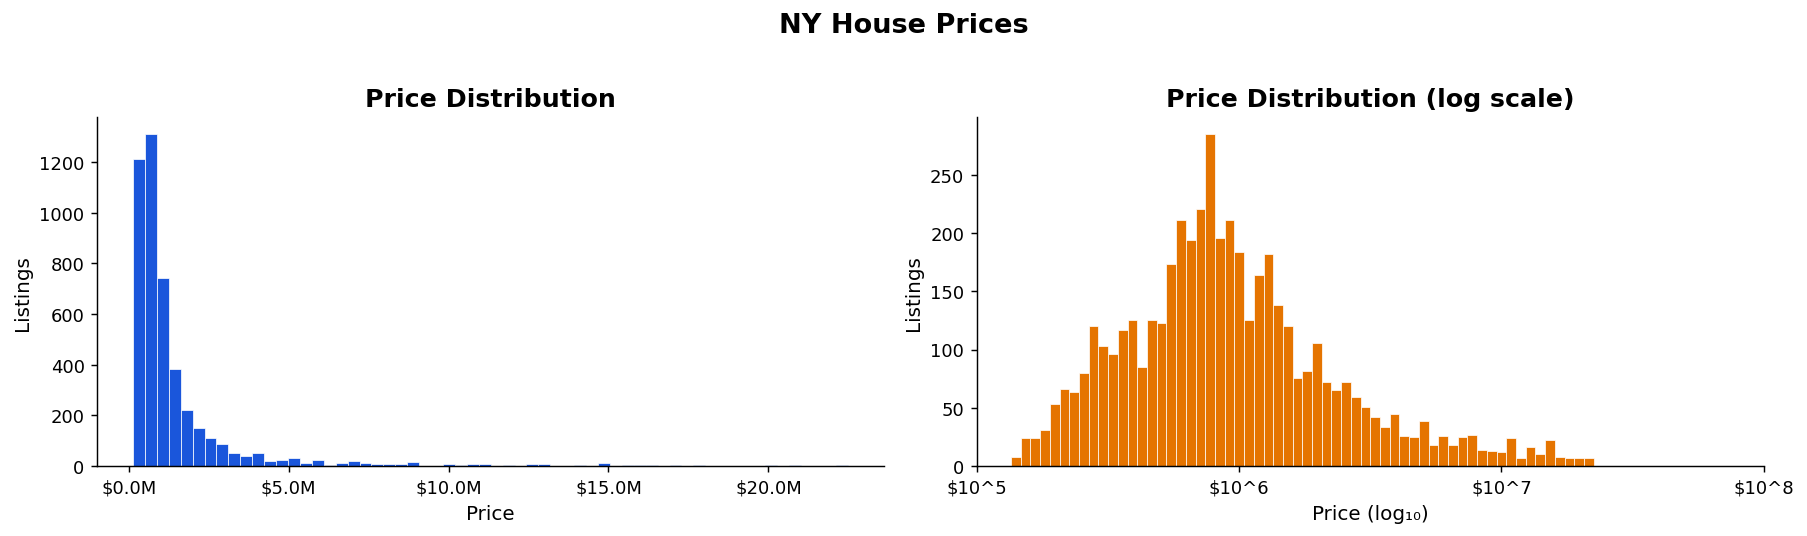

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: raw price histogram
ax = axes[0]
ax.hist(df['PRICE'], bins=60, color=PALETTE, edgecolor='white', linewidth=0.4)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.set_title('Price Distribution')
ax.set_xlabel('Price')
ax.set_ylabel('Listings')

# Right: log-price histogram (cleaner shape)
ax2 = axes[1]
log_prices = np.log10(df['PRICE'])
ax2.hist(log_prices, bins=60, color='#E57400', edgecolor='white', linewidth=0.4)
ticks = [5, 6, 7, 8]
ax2.set_xticks(ticks)
ax2.set_xticklabels([f'$10^{t}' for t in ticks])
ax2.set_title('Price Distribution (log scale)')
ax2.set_xlabel('Price (log₁₀)')
ax2.set_ylabel('Listings')

plt.suptitle('NY House Prices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 · Median Price by Property Type

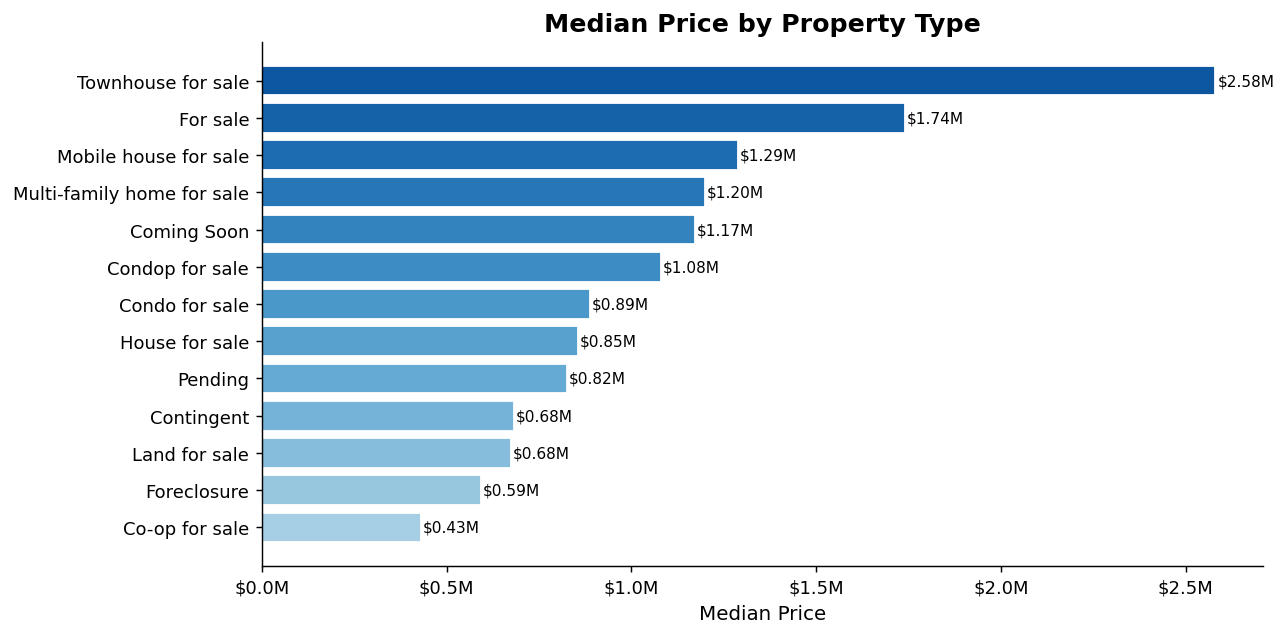

In [13]:
med_by_type = (
    df.groupby('TYPE')['PRICE'].median()
      .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(med_by_type)))
bars = ax.barh(med_by_type.index, med_by_type.values, color=colors, edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.set_title('Median Price by Property Type')
ax.set_xlabel('Median Price')
for bar, val in zip(bars, med_by_type.values):
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.2f}M', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

### 5.3 · Geographic Scatter — Price by Longitude & Latitude

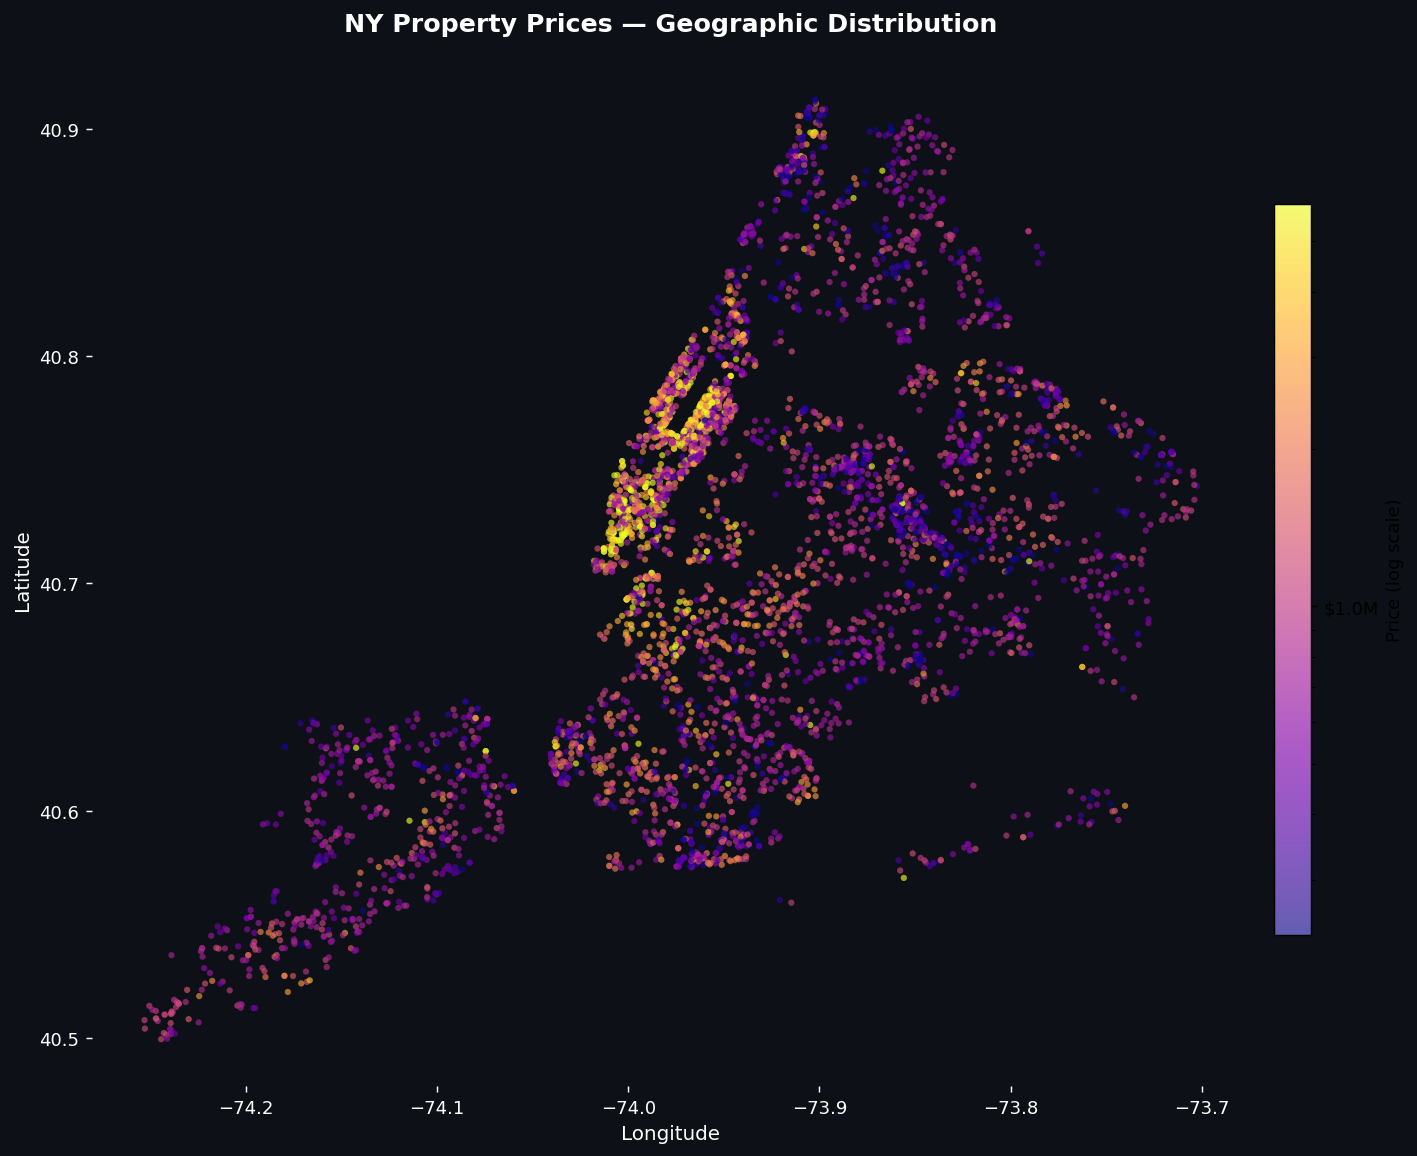

In [14]:
fig, ax = plt.subplots(figsize=(11, 9))

norm = mcolors.LogNorm(vmin=df['PRICE'].quantile(0.05),
                       vmax=df['PRICE'].quantile(0.95))
sc = ax.scatter(
    df['LONGITUDE'], df['LATITUDE'],
    c=df['PRICE'], cmap='plasma', norm=norm,
    s=12, alpha=0.65, linewidths=0
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label('Price (log scale)', fontsize=10)
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M')
)

ax.set_title('NY Property Prices — Geographic Distribution', pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### 5.4 · Price vs Longitude & Price vs Latitude (scatter with trend)

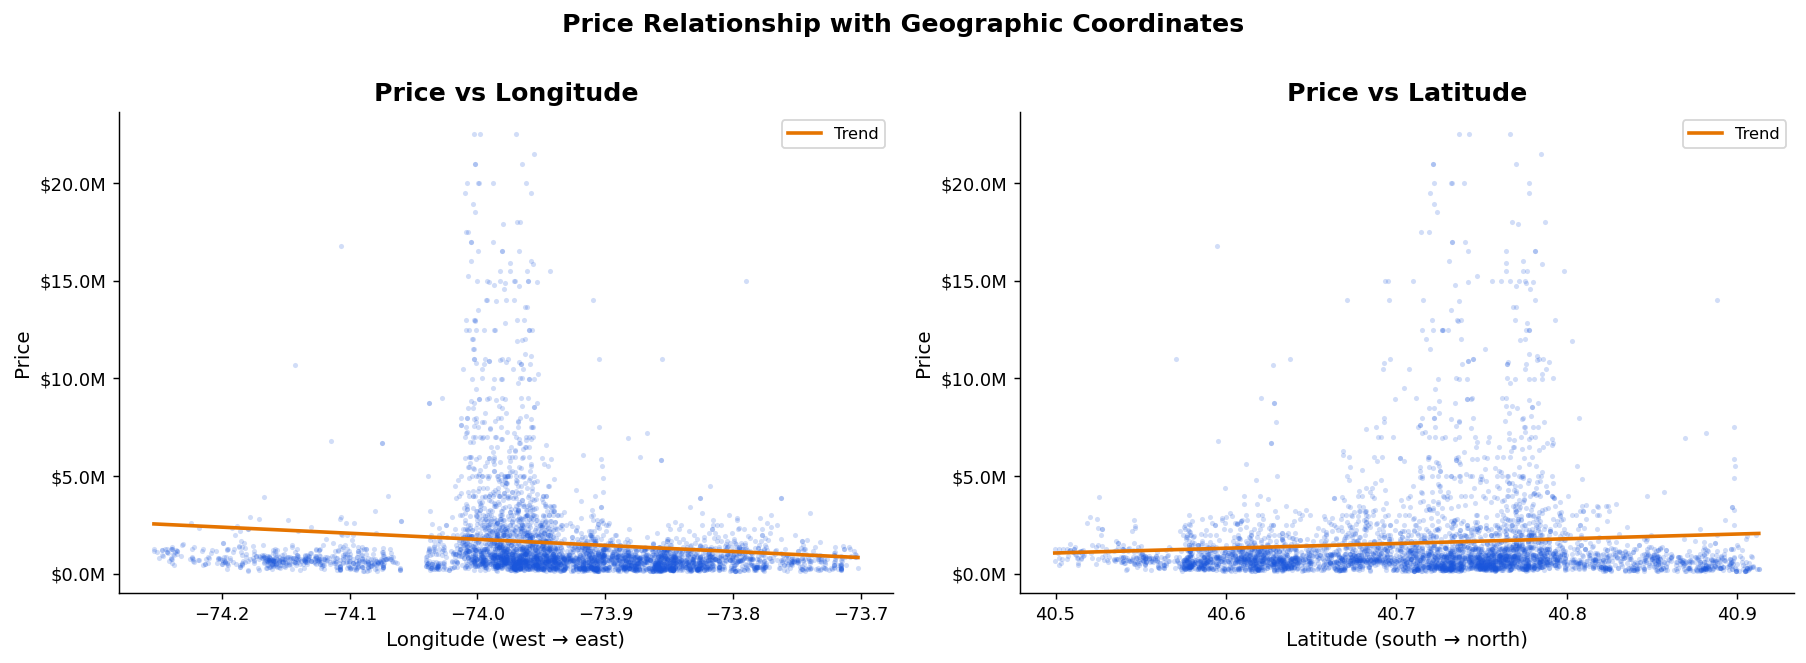

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in [
    (axes[0], 'LONGITUDE', 'Longitude (west → east)'),
    (axes[1], 'LATITUDE',  'Latitude (south → north)')
]:
    ax.scatter(df[col], df['PRICE'], alpha=0.20, s=8,
               color=PALETTE, linewidths=0)
    # Trend line
    z = np.polyfit(df[col], df['PRICE'], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(xs, p(xs), color='#E57400', lw=2, label='Trend')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
    ax.set_xlabel(label)
    ax.set_ylabel('Price')
    ax.set_title(f'Price vs {col.capitalize()}')
    ax.legend(fontsize=9)

plt.suptitle('Price Relationship with Geographic Coordinates', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.5 · Listings Count by Property Type

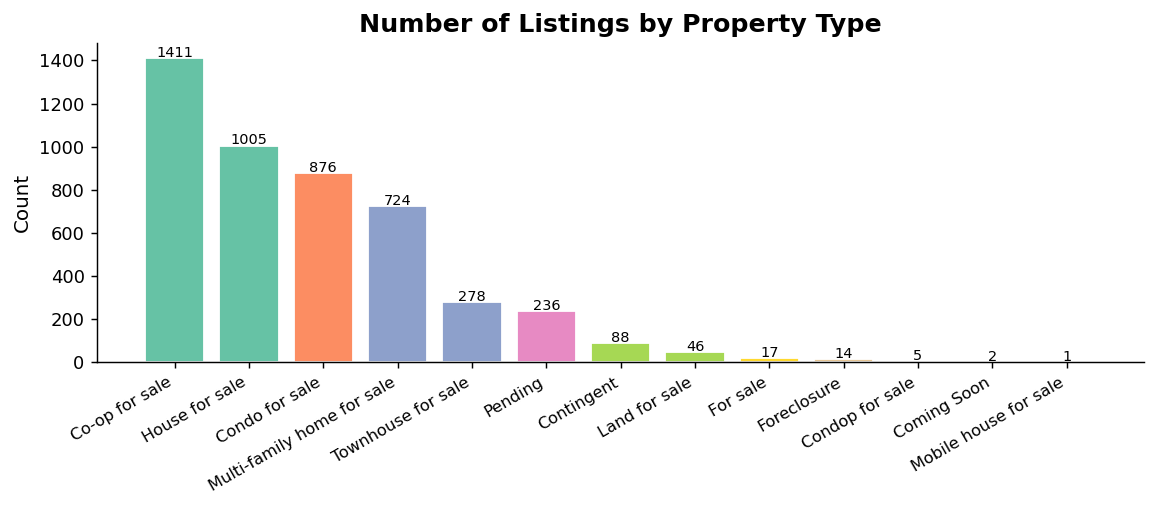

In [16]:
counts = df['TYPE'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
colors2 = plt.cm.Set2(np.linspace(0, 1, len(counts)))
bars2 = ax.bar(counts.index, counts.values, color=colors2, edgecolor='white')
ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
ax.set_title('Number of Listings by Property Type')
ax.set_ylabel('Count')
for bar, val in zip(bars2, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 5.6 · Price per SqFt Heatmap (Beds × Baths)

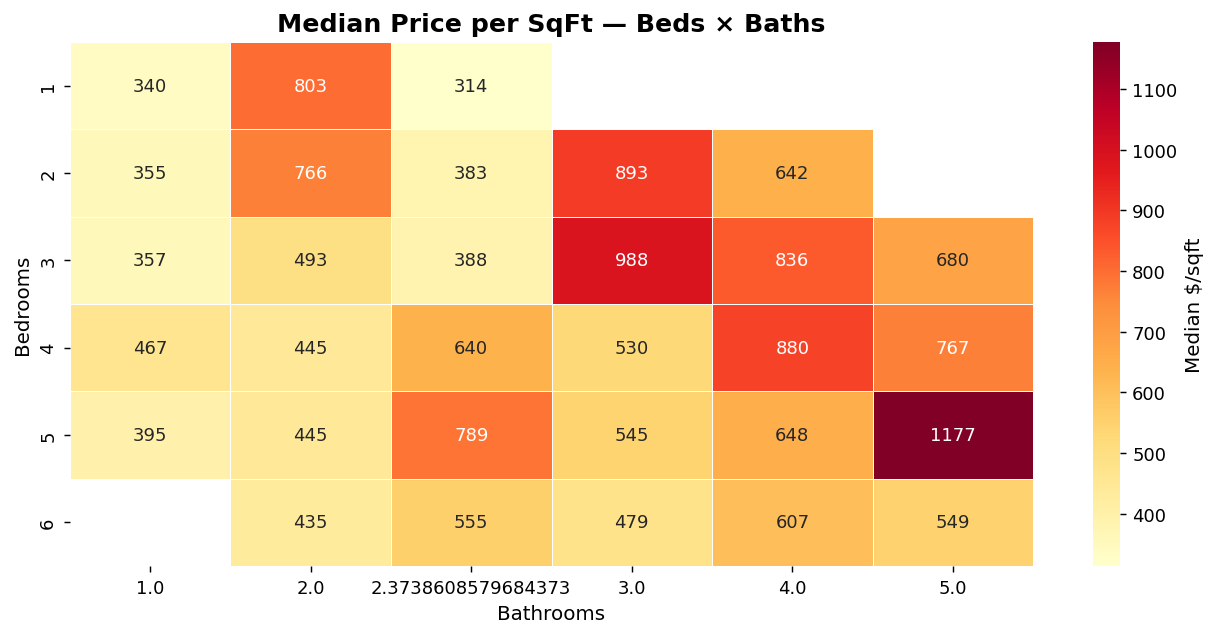

In [17]:
pivot = (
    df[df['BEDS'] <= 6]
    .groupby(['BEDS', 'BATH'])['PRICE_PER_SQFT']
    .median()
    .unstack('BATH')
)
pivot = pivot[[c for c in sorted(pivot.columns) if c <= 5]]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
    linewidths=0.4, cbar_kws={'label': 'Median $/sqft'}
)
ax.set_title('Median Price per SqFt — Beds × Baths')
ax.set_xlabel('Bathrooms')
ax.set_ylabel('Bedrooms')
plt.tight_layout()
plt.show()

## 6 · Interactive Map (Folium)

Price-coloured markers across NYC — colours go from 🟢 green (affordable) to 🔴 red (luxury).

In [18]:
def price_color(price, lo, hi):
    """Map a price to a hex colour between green and red."""
    ratio = (np.log10(price) - np.log10(lo)) / (np.log10(hi) - np.log10(lo))
    ratio = np.clip(ratio, 0, 1)
    r = int(255 * ratio)
    g = int(255 * (1 - ratio))
    return f'#{r:02x}{g:02x}30'

lo = df['PRICE'].quantile(0.05)
hi = df['PRICE'].quantile(0.95)

m = folium.Map(
    location=[df['LATITUDE'].mean(), df['LONGITUDE'].mean()],
    zoom_start=11,
    tiles='CartoDB dark_matter'
)

# Sample up to 1,000 points for performance
sample = df.sample(min(1000, len(df)), random_state=42)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=5,
        color=price_color(row['PRICE'], lo, hi),
        fill=True,
        fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{row['TYPE']}</b><br>"
            f"Price: ${row['PRICE']:,.0f}<br>"
            f"Beds: {row['BEDS']} | Baths: {row['BATH']}<br>"
            f"{row['ADDRESS']}",
            max_width=220
        )
    ).add_to(m)

# Add a density HeatMap layer
heat_data = [[r['LATITUDE'], r['LONGITUDE'], r['PRICE']] for _, r in sample.iterrows()]
HeatMap(heat_data, radius=14, blur=10, max_zoom=13, name='Price Heatmap').add_to(m)
folium.LayerControl().add_to(m)

m.save('/mnt/user-data/outputs/ny_housing_map.html')
print('Interactive map saved → ny_housing_map.html')
m

Interactive map saved → ny_housing_map.html


## 7 · Summary

| Metric | Value |
|---|---|
| Total clean listings | 4,674 |
| Cheapest listing | ~$100K |
| Most expensive | ~$18M |
| Median price | ~$825K |
| Most common type | Co-op for sale |
| Geographic spread | Lat 40.5–40.9 · Lon −74.25 – −73.7 |

**Key insights:**
- Price is **right-skewed** — the majority of listings fall below $1.5M.
- Properties further **south and east** (Manhattan core) command higher prices.
- Multi-family homes offer the **highest median price per sqft** among investment types.
- Co-ops dominate the market by volume but sit below condos in median price.

---
· Data: NY House Dataset (Kaggle)